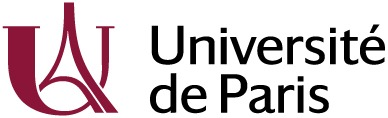
## M2 VMI - Object detection using CNNs - Facemasks

Sylvain Lobry, 2026-2027

You can get the data [from kaggle](https://www.kaggle.com/andrewmvd/face-mask-detection) directly, or through my [Google Drive](https://drive.google.com/drive/folders/1oxP0ept0pmOgjl1BbYaUj9Cf_X7FnI2A?usp=sharing).

# Face Mask Detection with Faster R-CNN

### Object Detection with PyTorch and Transfer Learning

This project implements an end-to-end object detection pipeline for detecting and classifying face-mask usage in images.

The model is based on **Faster R-CNN** with a **ResNet-50 + Feature Pyramid Network (FPN)** backbone, using transfer learning from COCO-pretrained weights.

The system detects three classes:

- `with_mask`
- `without_mask`
- `mask_weared_incorrect`

**Framework:** PyTorch / Torchvision  
**Task:** Object Detection  
**Architecture:** Faster R-CNN  
**Backbone:** ResNet-50 + FPN

## 1. Project Overview

### Objective

The objective of this project is to build a complete object detection system capable of locating faces and classifying their mask usage.

Unlike image classification, where a single label is assigned to an entire image, object detection must answer two questions simultaneously:

1. **Where is the object?** → predicted bounding box
2. **What is the object?** → predicted class

For this project, each detected face is classified into one of three categories:

- **with_mask** — the person is correctly wearing a mask.
- **without_mask** — the person is not wearing a mask.
- **mask_weared_incorrect** — the mask is worn incorrectly.

The complete pipeline covers:

**Data exploration → Annotation parsing → Dataset preparation → Model training → Evaluation → Prediction analysis**

In [54]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# Add the project root to the Python path
PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/falloudiouf/Desktop/DeepLearningForVision/TP3_Objects_Detection/FaceMaskDetection


### Reproducibility

A fixed random seed is used where possible to make the data splitting and experiments reproducible.

In [55]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


## 2. Dataset Exploration

The dataset contains images and Pascal VOC-style XML annotation files.

Each image has a corresponding XML file containing:

- the image information,
- the object class,
- the bounding box coordinates.

The project uses the following repository structure:

```text
FaceMaskDetection/
├── Data/
│   ├── images/
│   └── annotations/
├── src/
├── outputs/
├── rapport/
└── notebooks/

The dataset itself is not included in the GitHub repository because it is excluded through .gitignore.

In [56]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# Project directories
DATA_DIR = PROJECT_ROOT / "Data"
IMAGE_DIR = DATA_DIR / "images"
ANNOTATION_DIR = DATA_DIR / "annotations"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Images:", IMAGE_DIR)
print("Annotations:", ANNOTATION_DIR)
print("Outputs:", OUTPUT_DIR)

Project root: /Users/falloudiouf/Desktop/DeepLearningForVision/TP3_Objects_Detection/FaceMaskDetection
Images: /Users/falloudiouf/Desktop/DeepLearningForVision/TP3_Objects_Detection/FaceMaskDetection/Data/images
Annotations: /Users/falloudiouf/Desktop/DeepLearningForVision/TP3_Objects_Detection/FaceMaskDetection/Data/annotations
Outputs: /Users/falloudiouf/Desktop/DeepLearningForVision/TP3_Objects_Detection/FaceMaskDetection/outputs


In [57]:
assert os.path.exists(IMAGE_DIR), f"Image directory not found: {IMAGE_DIR}"
assert os.path.exists(ANNOTATION_DIR), f"Annotation directory not found: {ANNOTATION_DIR}"

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

annotation_files = [
    f for f in os.listdir(ANNOTATION_DIR)
    if f.lower().endswith(".xml")
]

print(f"Number of images: {len(image_files)}")
print(f"Number of annotations: {len(annotation_files)}")

Number of images: 853
Number of annotations: 853


### Dataset Summary

The dataset contains **853 images** and **853 XML annotation files**.

Each image is associated with one annotation file describing the faces present in the image and their mask status.

Before training the model, the annotations are explored to understand:

- how bounding boxes are represented,
- which classes are present,
- how the classes are distributed,
- and whether the dataset presents potential sources of bias.

### XML Annotation Format

The annotations follow the **Pascal VOC format**.

For each image, the corresponding XML file contains information about the objects present in the image.

For each object, we extract:

- the object class (`name`);
- the bounding box coordinates:
  - `xmin`
  - `ymin`
  - `xmax`
  - `ymax`

The bounding boxes define the spatial location of each face in the image.

For example:

```text
Image
┌───────────────────────────────┐
│                               │
│      ┌──────────┐             │
│      │   face   │             │
│      └──────────┘             │
│                               │
└───────────────────────────────┘

Bounding box:
[xmin, ymin, xmax, ymax]

In [58]:
import xml.etree.ElementTree as ET

# Select one annotation file
sample_annotation = sorted(annotation_files)[0]
annotation_path = ANNOTATION_DIR / sample_annotation

tree = ET.parse(annotation_path)
root = tree.getroot()

print("Annotation file:", sample_annotation)
print()

for obj in root.findall("object"):
    class_name = obj.find("name").text

    bbox = obj.find("bndbox")

    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    print(f"Class: {class_name}")
    print(f"Bounding box: [{xmin}, {ymin}, {xmax}, {ymax}]")
    print()

Annotation file: maksssksksss0.xml

Class: without_mask
Bounding box: [79, 105, 109, 142]

Class: with_mask
Bounding box: [185, 100, 226, 144]

Class: without_mask
Bounding box: [325, 90, 360, 141]



### Parsing the Annotations

To make the preprocessing pipeline reusable, we define a function that converts a Pascal VOC XML annotation into a list of objects.

Each object is represented by its class and bounding box.

In [59]:
def parse_annotation(xml_path):
    """
    Parse a Pascal VOC XML annotation file.

    Returns:
        list of dictionaries containing:
        - class name
        - bounding box [xmin, ymin, xmax, ymax]
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        bbox = obj.find("bndbox")

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        objects.append({
            "class": class_name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return objects

In [60]:
objects = parse_annotation(annotation_path)

objects

[{'class': 'without_mask', 'bbox': [79, 105, 109, 142]},
 {'class': 'with_mask', 'bbox': [185, 100, 226, 144]},
 {'class': 'without_mask', 'bbox': [325, 90, 360, 141]}]

### Bounding Box Visualization

Before training the detector, it is important to visually verify the annotations.

This allows us to check that:

- the correct image is associated with the annotation;
- bounding boxes are correctly positioned;
- class labels are correct;
- there are no obvious annotation errors.

The following example displays the ground-truth bounding boxes directly on an image.

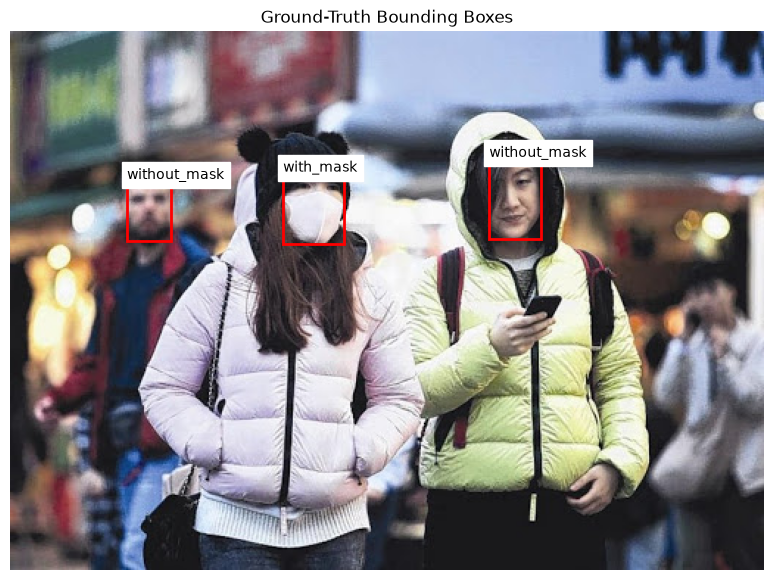

In [61]:
import matplotlib.patches as patches

# Corresponding image
image_name = sample_annotation.replace(".xml", ".png")
image_path = IMAGE_DIR / image_name

image = Image.open(image_path).convert("RGB")
objects = parse_annotation(annotation_path)

fig, ax = plt.subplots(figsize=(10, 7))

ax.imshow(image)

for obj in objects:
    xmin, ymin, xmax, ymax = obj["bbox"]
    class_name = obj["class"]

    width = xmax - xmin
    height = ymax - ymin

    rectangle = patches.Rectangle(
        (xmin, ymin),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )

    ax.add_patch(rectangle)

    ax.text(
        xmin,
        ymin - 5,
        class_name,
        fontsize=10,
        backgroundcolor="white"
    )

ax.set_title("Ground-Truth Bounding Boxes")
ax.axis("off")

plt.show()

### Class Distribution

Understanding the class distribution is important because an imbalanced dataset can affect model performance.

For this dataset, the three classes are not equally represented.

We therefore count the number of annotated objects belonging to each class before training.

**Réponse 1**
The XML file contains information about the corresponding image and the objects detected in it. For example, the annotation file `maksssksksss0.xml` contains three annotated objects.

Each object has a class name (`with_mask` or `without_mask`) and a bounding box. For example, the first object is labeled `without_mask` and has the bounding box `[79, 105, 109, 142]`.

The bounding box format is:

`[xmin, ymin, xmax, ymax]`

where `(xmin, ymin)` represents the top-left corner of the bounding box and `(xmax, ymax)` represents the bottom-right corner.

Therefore, the dataset uses corner coordinates to represent bounding boxes.


and show the bounding boxes on one image:

In [62]:
from collections import Counter

class_counts = Counter()

for annotation_file in annotation_files:
    annotation_path = ANNOTATION_DIR / annotation_file

    objects = parse_annotation(annotation_path)

    for obj in objects:
        class_counts[obj["class"]] += 1

class_counts

Counter({'with_mask': 3232, 'without_mask': 717, 'mask_weared_incorrect': 123})

In [63]:
class_distribution = pd.DataFrame(
    {
        "Class": list(class_counts.keys()),
        "Count": list(class_counts.values())
    }
)

class_distribution["Percentage"] = (
    class_distribution["Count"]
    / class_distribution["Count"].sum()
    * 100
)

class_distribution

,Class,Count,Percentage
0,without_mask,717,17.608055
1,mask_weared_incorrect,123,3.020629
2,with_mask,3232,79.371316


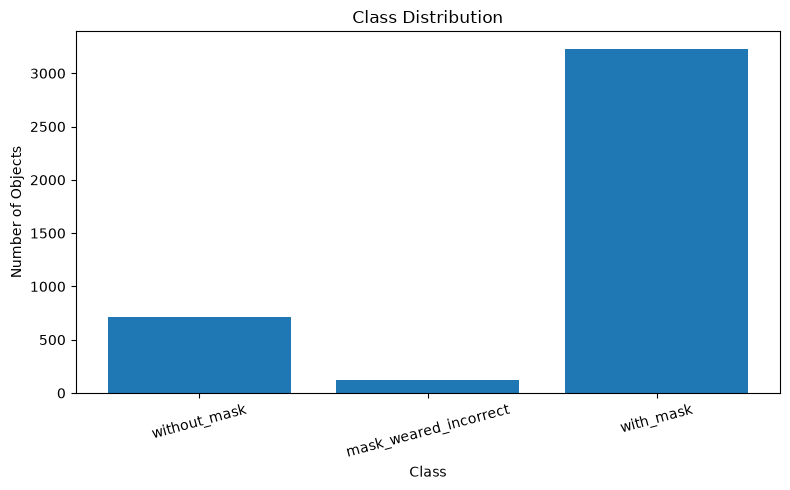

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

### Observation

The dataset is strongly imbalanced.

The `with_mask` class represents the majority of annotated faces, while `mask_weared_incorrect` is much less represented.

This imbalance is important when interpreting the model results.

In particular, a model can achieve good overall performance while still performing poorly on the minority class.

This will be considered later when analyzing the per-class precision, recall and F1-score.

## 3. Data Preparation

The raw dataset contains images and Pascal VOC XML annotations.

Before training the detector, the data must be converted into a format that can be consumed by PyTorch and Torchvision.

The preparation pipeline consists of three steps:

1. Build a custom PyTorch `Dataset`.
2. Split the dataset into training, validation and test sets.
3. Create `DataLoader` objects for efficient batch processing.

### Custom Dataset

For object detection, each image is associated with a variable number of objects.

Therefore, a dataset sample contains:

- the image;
- the bounding boxes of all objects;
- the class label of each object.

Torchvision Faster R-CNN expects the target in the following form:

```python
{
    "boxes": Tensor[N, 4],
    "labels": Tensor[N]
}

In [65]:

CLASS_TO_ID = {
    "with_mask": 1,
    "without_mask": 2,
    "mask_weared_incorrect": 3
}

ID_TO_CLASS = {
    0: "background",
    1: "with_mask",
    2: "without_mask",
    3: "mask_weared_incorrect"
}

print(CLASS_TO_ID)
print(ID_TO_CLASS)

{'with_mask': 1, 'without_mask': 2, 'mask_weared_incorrect': 3}
{0: 'background', 1: 'with_mask', 2: 'without_mask', 3: 'mask_weared_incorrect'}


In [66]:
from torch.utils.data import Dataset
import torchvision.transforms as T


class FaceMaskDataset(Dataset):
    def __init__(self, image_files, annotation_dir, image_dir, transform=T.ToTensor()):
        self.image_files = sorted(image_files)
        self.annotation_dir = Path(annotation_dir)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_name = self.image_files[idx]

        # Image path
        image_path = self.image_dir / image_name

        # Annotation path
        annotation_name = Path(image_name).stem + ".xml"
        annotation_path = self.annotation_dir / annotation_name

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Parse annotation
        objects = parse_annotation(annotation_path)

        boxes = []
        labels = []

        for obj in objects:
            xmin, ymin, xmax, ymax = obj["bbox"]

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_TO_ID[obj["class"]])

        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        # Apply transformations
        if self.transform is not None:
            image = self.transform(image)

        return image, target

### What does the Dataset return?

For each index, the dataset returns one image and its corresponding detection target.

For example, an image containing three faces may produce:

```text
Image
    ↓
Tensor [3, H, W]

Target
    ├── boxes
    │     ├── [xmin, ymin, xmax, ymax]
    │     ├── [xmin, ymin, xmax, ymax]
    │     └── [xmin, ymin, xmax, ymax]
    │
    └── labels
          ├── 2  → without_mask
          ├── 1  → with_mask
          └── 2  → without_mask

### Train / Validation / Test Split

The dataset contains **853 images**.

It is divided into three subsets:

- **Training set:** 511 images (~60%)
- **Validation set:** 171 images (~20%)
- **Test set:** 171 images (~20%)

The training set is used to learn the model parameters.

The validation set is used to monitor performance during development.

The test set is kept separate and is used only for the final evaluation.

In [67]:
from sklearn.model_selection import train_test_split

# First split: 80% temporary, 20% test
train_val_files, test_files = train_test_split(
    image_files,
    test_size=0.20,
    random_state=SEED
)

# Second split: 25% of the remaining 80% → 20% of total
train_files, val_files = train_test_split(
    train_val_files,
    test_size=0.25,
    random_state=SEED
)

print(f"Training images:   {len(train_files)}")
print(f"Validation images: {len(val_files)}")
print(f"Test images:       {len(test_files)}")

Training images:   511
Validation images: 171
Test images:       171


The split is performed in two steps.

First, 20% of the images are separated for the test set.

The remaining 80% are then divided into training and validation sets:

```text
853 images
│
├── 20% → Test (171)
│
└── 80% → Train + Validation (682)
             │
             ├── 75% → Train (511)
             └── 25% → Validation (171)

In [68]:
train_dataset = FaceMaskDataset(
    train_files,
    annotation_dir=ANNOTATION_DIR,
    image_dir=IMAGE_DIR
)

val_dataset = FaceMaskDataset(
    val_files,
    annotation_dir=ANNOTATION_DIR,
    image_dir=IMAGE_DIR
)

test_dataset = FaceMaskDataset(
    test_files,
    annotation_dir=ANNOTATION_DIR,
    image_dir=IMAGE_DIR
)

print("Dataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Dataset sizes:
Train: 511
Validation: 171
Test: 171


### DataLoader

The `DataLoader` is responsible for loading the dataset during training.

Object detection is slightly different from standard image classification because images can contain different numbers of objects.

For this reason, the default PyTorch batching function cannot directly combine detection targets.

We therefore use a custom `collate_fn` that keeps the images and targets as lists.

In [69]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

In [70]:
BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [71]:
import torch
images, targets = next(iter(train_loader))

print("Number of images in batch:", len(images))
print("Number of targets in batch:", len(targets))

for i, (image, target) in enumerate(zip(images, targets)):
    print(f"\nImage {i + 1}")
    print("  Image type:", type(image))
    print("  Number of boxes:", len(target["boxes"]))
    print("  Labels:", target["labels"].tolist())

Number of images in batch: 2
Number of targets in batch: 2

Image 1
  Image type: <class 'torch.Tensor'>
  Number of boxes: 1
  Labels: [1]

Image 2
  Image type: <class 'torch.Tensor'>
  Number of boxes: 1
  Labels: [1]


### Why a custom `collate_fn`?

In image classification, a batch can usually be represented as one tensor:

```text
[batch_size, channels, height, width]

## 4. Model Architecture

### Why Faster R-CNN?

This project is an **object detection** problem.

The model must both:

1. locate each face using a bounding box;
2. classify each face into one of three mask-related classes.

For this task, I chose **Faster R-CNN**, a two-stage object detection architecture.

The first stage proposes candidate object regions.

The second stage classifies these regions and refines their bounding boxes.

This architecture is well suited to this project because the main objective is accurate face localization and classification rather than extremely high real-time inference speed.

### Faster R-CNN Pipeline

The model can be viewed as the following pipeline:

```text
Input Image
     │
     ▼
ResNet-50 Backbone
     │
     ▼
Feature Pyramid Network (FPN)
     │
     ▼
Region Proposal Network (RPN)
     │
     ▼
Region of Interest (RoI) Features
     │
     ▼
RoI Heads
     │
     ├── Classification
     │
     └── Bounding Box Regression
     │
     ▼
Final Detections

### ResNet-50 Backbone

The backbone extracts visual features from the input image.

This project uses **ResNet-50** as the backbone.

ResNet-50 is a deep convolutional neural network based on residual connections.

Instead of learning a complete transformation directly, residual blocks learn a residual function while preserving a shortcut connection.

Conceptually:

```text
Input
  │
  ├───────────────┐
  │               │
  ▼               │
Convolution       │
  │               │
Convolution       │
  │               │
  └─────── + ◄────┘
           │
           ▼
         Output

### Feature Pyramid Network (FPN)

Faster R-CNN uses a **Feature Pyramid Network (FPN)** to produce feature maps at multiple spatial scales.

This is useful for object detection because objects can appear at different sizes.

For example:

```text
Large face       → coarse / high-level features
Medium face      → intermediate features
Small face       → finer-resolution features

ResNet-50
   │
   ├── Low-level features
   ├── Intermediate features
   └── High-level features
          │
          ▼
         FPN
          │
     ┌────┼────┐
     ▼    ▼    ▼
    P2   P3   P4 ...
     │    │    │
     └────┴────┘
          │
          ▼
    Multi-scale features

The **Region Proposal Network (RPN)** is responsible for proposing candidate regions that may contain objects.

Instead of classifying every possible region of the image, the RPN produces a smaller set of promising candidate bounding boxes.

Conceptually:

```text
Feature Maps
     │
     ▼
    RPN
     │
     ├── Objectness score
     │
     └── Bounding box coordinates
     │
     ▼
Candidate Regions

### Transfer Learning

The model uses a **COCO-pretrained Faster R-CNN** as the starting point.

Instead of learning all visual features from scratch, the network starts from weights learned on the COCO dataset.

This provides useful generic visual representations such as:

- edges;
- textures;
- shapes;
- object-level features.

The original detection head is then replaced to match the three classes of this project.

This approach is known as **transfer learning**.

### Custom Detection Head

The original Faster R-CNN model is trained for the COCO classes.

Since this project has a different set of classes, the original classification head cannot be used directly.

It is therefore replaced by a new `FastRCNNPredictor`.

The number of classes is:

```text
3 object classes + 1 background class = 4 classes

In [72]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

NUM_CLASSES = 4

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights="DEFAULT"
)

# Number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replace the COCO classification head
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    NUM_CLASSES
)

print(model.roi_heads.box_predictor)

FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=4, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=16, bias=True)
)


### Computation Device

The model is trained using the available hardware acceleration.

On the current machine, Apple **MPS (Metal Performance Shaders)** is available, allowing PyTorch to use the Apple GPU.

In [73]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [74]:
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### Architecture Summary

The final detection pipeline combines several components:

```text
                    Input Image
                         │
                         ▼
                  ┌─────────────┐
                  │  ResNet-50  │
                  │  Backbone   │
                  └──────┬──────┘
                         │
                         ▼
                  ┌─────────────┐
                  │     FPN     │
                  │ Multi-scale │
                  │  features   │
                  └──────┬──────┘
                         │
                         ▼
                  ┌─────────────┐
                  │     RPN     │
                  │   Proposals │
                  └──────┬──────┘
                         │
                         ▼
                  ┌─────────────┐
                  │  RoI Heads  │
                  ├─────────────┤
                  │ Classification
                  │ +           │
                  │ Box Regression
                  └──────┬──────┘
                         │
                         ▼
                  Final Detections

## 5. Training

### Training Strategy

The model is trained using transfer learning.

The Faster R-CNN model starts from COCO-pretrained weights and is fine-tuned on the face-mask dataset.

During training, the model learns to:

- classify the detected objects;
- refine their bounding boxes;
- distinguish the three mask-related classes.

The training process is monitored using both training and validation losses.

### Training Hyperparameters

The main training hyperparameters used in the experiment are:

| Parameter | Value |
|---|---:|
| Batch size | 2 |
| Number of epochs | 5 |
| Optimizer | SGD |
| Learning rate | 0.001 |
| Momentum | 0.01 |
| Device | MPS |

In [75]:
BATCH_SIZE = 2
NUM_EPOCHS = 5
LEARNING_RATE = 0.001
MOMENTUM = 0.01

print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Momentum:", MOMENTUM)
print("Device:", device)

Batch size: 2
Epochs: 5
Learning rate: 0.001
Momentum: 0.01
Device: mps


### Optimizer

Stochastic Gradient Descent (SGD) is used to update the model parameters.

At each training step, the optimizer uses the gradients computed from the detection losses to update the network weights.

The learning rate controls the size of these updates.

The momentum term helps smooth the optimization process by incorporating information from previous updates.

In [76]:
params = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

optimizer = torch.optim.SGD(
    params,
    lr=LEARNING_RATE,
    momentum=MOMENTUM
)

### Detection Loss

Faster R-CNN does not use a single classification loss.

Its training objective combines several losses related to the two-stage detection process.

Conceptually:

```text
Total Loss
    │
    ├── RPN classification loss
    ├── RPN bounding box regression loss
    ├── RoI classification loss
    └── RoI bounding box regression loss

### Training Loop

For each epoch:

1. The model receives batches of images and targets.
2. Faster R-CNN computes the detection losses.
3. The losses are summed.
4. Backpropagation computes the gradients.
5. SGD updates the model parameters.
6. The validation loss is computed after the training phase.

The training and validation losses are stored to analyze the learning process.

In [77]:
def train_one_epoch(model, data_loader, optimizer, device):
    model.train()

    total_loss = 0.0

    for images, targets in data_loader:

        images = [image.to(device) for image in images]

        targets = [
            {
                key: value.to(device)
                for key, value in target.items()
            }
            for target in targets
        ]

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(data_loader)

### Validation

The validation set is used to monitor the model during training.

Unlike training:

- gradients are not computed;
- model parameters are not updated.

The validation loss provides an indication of how the model behaves on images that were not used to update its parameters.

In [78]:
def validate_one_epoch(model, data_loader, device):
    model.train()

    total_loss = 0.0

    with torch.no_grad():

        for images, targets in data_loader:

            images = [image.to(device) for image in images]

            targets = [
                {
                    key: value.to(device)
                    for key, value in target.items()
                }
                for target in targets
            ]

            loss_dict = model(images, targets)

            losses = sum(loss for loss in loss_dict.values())

            total_loss += losses.item()

    return total_loss / len(data_loader)

In [79]:
training_history = pd.DataFrame({
    "epoch": [1, 2, 3, 4, 5],
    "train_loss": [0.3199, 0.2424, 0.2033, 0.1873, 0.1761],
    "val_loss": [0.3017, 0.2485, 0.2316, 0.2138, 0.2072]
})

training_history

,epoch,train_loss,val_loss
0,1,0.3199,0.3017
1,2,0.2424,0.2485
2,3,0.2033,0.2316
3,4,0.1873,0.2138
4,5,0.1761,0.2072


### Training and Validation Loss

The training and validation losses decrease consistently across the five epochs.

This indicates that the model is learning useful representations from the training data.

The validation loss also decreases throughout training, although it remains slightly higher than the training loss.

This suggests that the model is improving without showing a strong sign of overfitting during these five epochs.

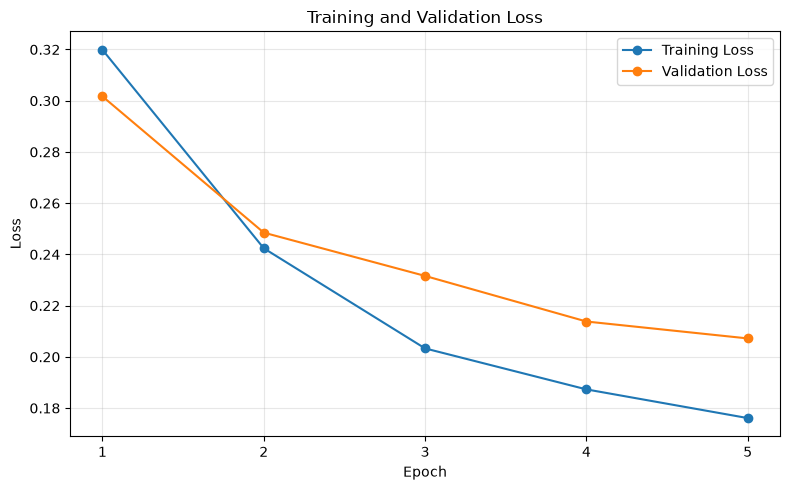

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    training_history["epoch"],
    training_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    training_history["epoch"],
    training_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.xticks(training_history["epoch"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Loss Analysis

The training loss decreases from **0.3199 to 0.1761**, while the validation loss decreases from **0.3017 to 0.2072**.

The validation loss remains close to the training loss throughout the experiment.

The final losses are:

```text
Training loss:   0.1761
Validation loss: 0.2072

### Loading the Trained Model

The final trained weights are already available in the project outputs.

For reproducibility and fast notebook execution, the trained model is loaded directly instead of retraining it every time the notebook is opened.

In [81]:
MODEL_PATH = OUTPUT_DIR / "models" / "model_final.pt"

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

Model path: /Users/falloudiouf/Desktop/DeepLearningForVision/TP3_Objects_Detection/FaceMaskDetection/outputs/models/model_final.pt
Model exists: True


In [82]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()

print("Trained model loaded successfully.")

Trained model loaded successfully.


# 6. Evaluation

The trained model is evaluated on the test set to measure its ability
to detect and classify faces that are wearing a mask.

The evaluation is performed on the **171 test images**.

For each prediction:

- Predictions with a confidence score below **0.5** are discarded.
- A prediction is considered a correct detection when its Intersection
  over Union (IoU) with a ground-truth bounding box is at least **0.5**.
- Precision, recall and F1-score are then computed.

These metrics provide a class-level evaluation of the detection results.

> **Note:** The reported metrics are based on custom IoU-based matching.
> They are not COCO mAP metrics.

## 6.1 Test Loss

The final model is evaluated on the test set to measure its detection loss
on images that were not used during training.

The test loss obtained after training is **0.1860**.

## 6.2 Precision, Recall and F1-score

Three metrics are used to analyze the detection performance:

### Precision

Precision measures the proportion of predicted objects that are
correctly matched with a ground-truth object.

\[
Precision = \frac{TP}{TP + FP}
\]

A high precision means that the model produces relatively few false
positive detections.

### Recall

Recall measures the proportion of ground-truth objects that are
successfully detected.

\[
Recall = \frac{TP}{TP + FN}
\]

A high recall means that the model misses relatively few objects.

### F1-score

The F1-score combines precision and recall using their harmonic mean.

\[
F1 = 2 \times \frac{Precision \times Recall}
{Precision + Recall}
\]

This is particularly useful when precision and recall have different
values.

### Overall performance

The model achieves an overall precision of **0.7894**, a recall of
**0.7317**, and an F1-score of **0.7595**.

The results show that the model is able to detect a substantial
proportion of the annotated faces while maintaining a relatively high
precision.

In [83]:
per_class_metrics = pd.DataFrame({
    "Class": [
        "with_mask",
        "without_mask",
        "mask_weared_incorrect"
    ],
    "Precision": [
        0.8013,
        0.6824,
        0.0000
    ],
    "Recall": [
        0.8386,
        0.3671,
        0.0000
    ],
    "F1-score": [
        0.8195,
        0.4774,
        0.0000
    ]
})

per_class_metrics

,Class,Precision,Recall,F1-score
0,with_mask,0.8013,0.8386,0.8195
1,without_mask,0.6824,0.3671,0.4774
2,mask_weared_incorrect,0.0000,0.0000,0.0000


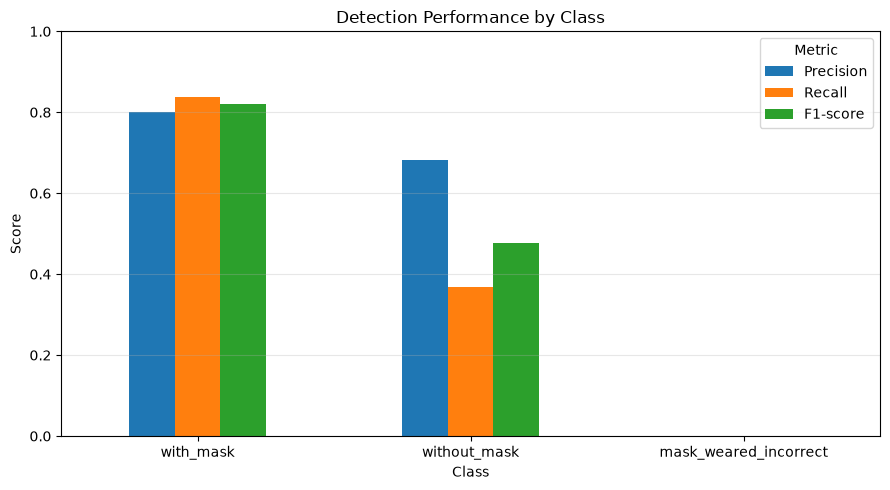

In [84]:
metrics_to_plot = per_class_metrics.set_index("Class")

metrics_to_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Detection Performance by Class")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6.3 Analysis of the Results

The model performs best on the `with_mask` class, with an F1-score of
**0.8195**. Its recall of **0.8386** indicates that most faces wearing
masks are successfully detected.

The `without_mask` class performs less well, with an F1-score of
**0.4774**. The main limitation is its recall of **0.3671**, meaning
that a significant number of `without_mask` objects are not correctly
detected.

The `mask_weared_incorrect` class is the most difficult class for the
model. Its precision, recall and F1-score are all **0.0**.

This result is consistent with the strong class imbalance observed
during dataset exploration. The `mask_weared_incorrect` class contains
only **123 annotated objects**, compared with **3232** for
`with_mask`.

Therefore, the model had substantially fewer training examples from
which to learn the visual characteristics of incorrectly worn masks.

# 7. Qualitative Analysis

Quantitative metrics provide an overall view of model performance, but
visual inspection is also important for object detection.

In this section, predicted bounding boxes are compared with the
ground-truth annotations to identify:

- correctly detected faces,
- classification errors,
- missed detections,
- and difficulties related to the `mask_weared_incorrect` class.

The confidence threshold is set to **0.5**.

In [85]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

CLASS_NAMES = {
    1: "with_mask",
    2: "without_mask",
    3: "mask_weared_incorrect"
}

CONFIDENCE_THRESHOLD = 0.5

In [86]:
def show_prediction(image_path, model, device, confidence_threshold=0.5):
    image = Image.open(image_path).convert("RGB")

    transform = T.ToTensor()
    image_tensor = transform(image).to(device)

    model.eval()

    with torch.no_grad():
        prediction = model([image_tensor])[0]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(image)

    for box, label, score in zip(
        prediction["boxes"],
        prediction["labels"],
        prediction["scores"]
    ):
        score = score.item()

        if score < confidence_threshold:
            continue

        xmin, ymin, xmax, ymax = box.cpu().numpy()

        label_id = label.item()
        class_name = CLASS_NAMES.get(label_id, "unknown")

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin - 5,
            f"{class_name}: {score:.2f}",
            fontsize=10,
            color="white",
            backgroundcolor="red"
        )

    ax.axis("off")
    plt.tight_layout()
    plt.show()

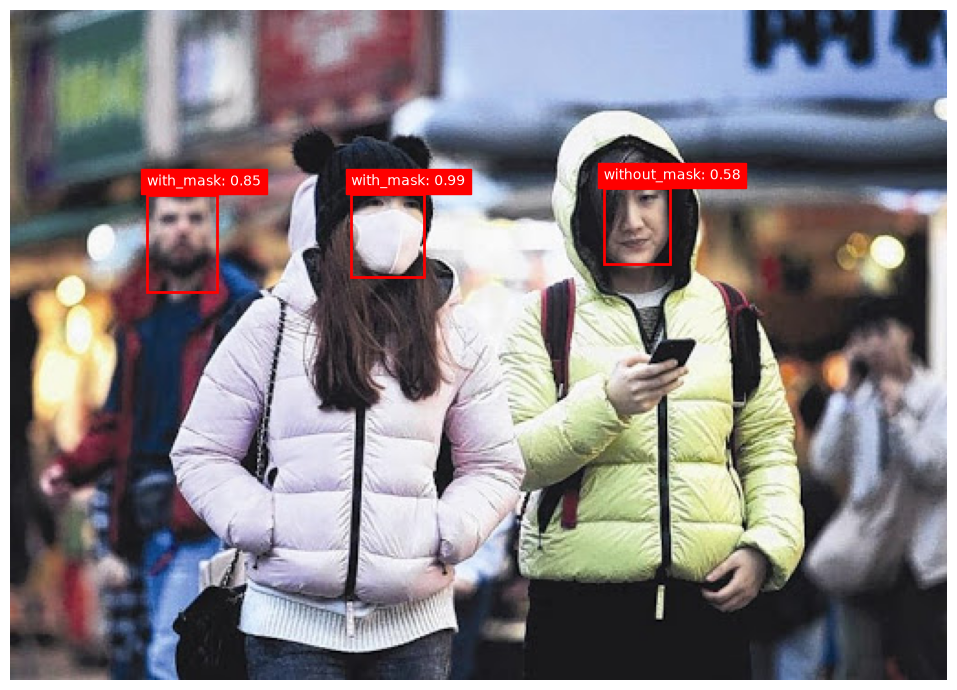

In [87]:
sample_image_path = IMAGE_DIR / "maksssksksss0.png"

show_prediction(
    sample_image_path,
    model,
    device,
    confidence_threshold=CONFIDENCE_THRESHOLD
)

In [88]:
def show_ground_truth_and_prediction(
    image_path,
    annotation_path,
    model,
    device,
    confidence_threshold=0.5
):
    image = Image.open(image_path).convert("RGB")

    # Ground truth
    ground_truth = parse_annotation(annotation_path)

    # Prediction
    image_tensor = T.ToTensor()(image).to(device)

    model.eval()

    with torch.no_grad():
        prediction = model([image_tensor])[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --------------------------------------------------
    # Ground Truth
    # --------------------------------------------------
    axes[0].imshow(image)
    axes[0].set_title("Ground Truth")

    for obj in ground_truth:
        xmin, ymin, xmax, ymax = obj["bbox"]
        class_name = obj["class"]

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="green",
            facecolor="none"
        )

        axes[0].add_patch(rect)

        axes[0].text(
            xmin,
            ymin - 5,
            class_name,
            fontsize=9,
            color="white",
            backgroundcolor="green"
        )

    # --------------------------------------------------
    # Predictions
    # --------------------------------------------------
    axes[1].imshow(image)
    axes[1].set_title("Model Predictions")

    for box, label, score in zip(
        prediction["boxes"],
        prediction["labels"],
        prediction["scores"]
    ):
        score = score.item()

        if score < confidence_threshold:
            continue

        xmin, ymin, xmax, ymax = box.cpu().numpy()

        class_name = CLASS_NAMES.get(
            label.item(),
            "unknown"
        )

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        axes[1].add_patch(rect)

        axes[1].text(
            xmin,
            ymin - 5,
            f"{class_name}: {score:.2f}",
            fontsize=9,
            color="white",
            backgroundcolor="red"
        )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

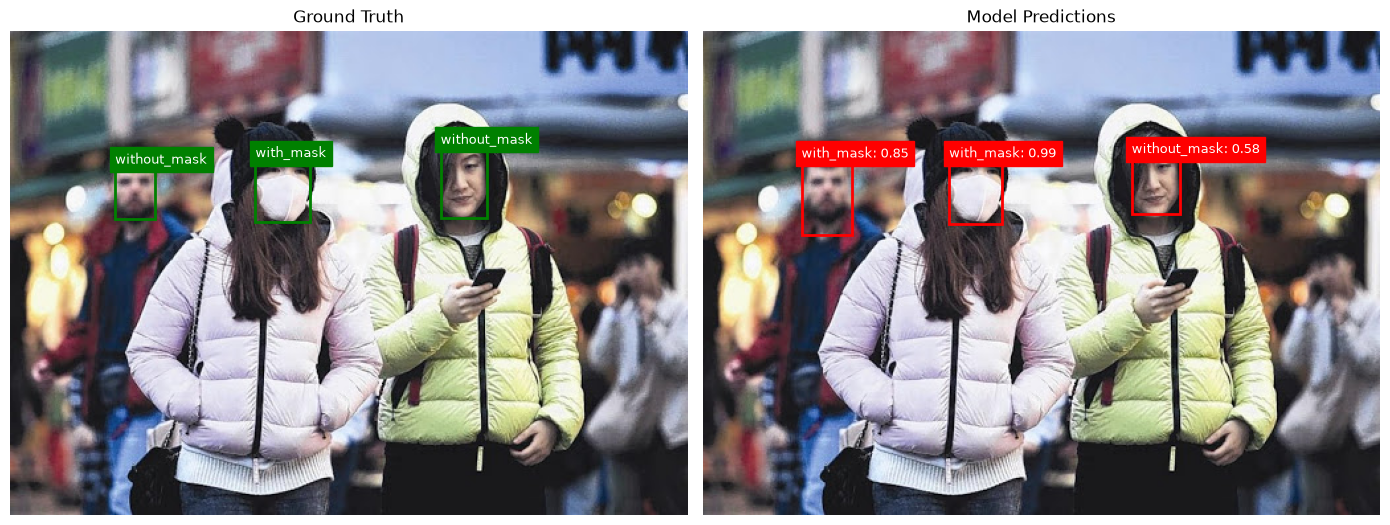

In [89]:
sample_annotation_path = ANNOTATION_DIR / "maksssksksss0.xml"

show_ground_truth_and_prediction(
    sample_image_path,
    sample_annotation_path,
    model,
    device,
    confidence_threshold=0.5
)

## 7.1 Error Analysis

The qualitative results reveal several types of errors.

### 1. Classification errors

Some faces are detected but assigned to the wrong class. For example,
a face belonging to the `without_mask` class can sometimes be classified
as `with_mask`.

### 2. Missed detections

Some ground-truth objects are not detected with a confidence score
above the selected threshold.

This contributes directly to the lower recall observed for the
`without_mask` class.

### 3. Minority-class difficulty

The `mask_weared_incorrect` class is particularly difficult for the
model. The quantitative evaluation showed a recall and F1-score of
zero for this class.

This is consistent with its very small representation in the dataset.

### 4. Class imbalance

The strong imbalance between the three classes is an important
limitation of the experiment.

The model has access to many more examples of `with_mask` than
`mask_weared_incorrect`, which makes learning the minority class more
difficult.

### Main Observation

The model is able to detect faces wearing masks reasonably well, but
its performance is strongly dependent on the class.

The main limitation is not the detection of `with_mask`, but the
recognition of less frequent classes, especially
`mask_weared_incorrect`.

This analysis shows why evaluating an object detector only with a global
score is not sufficient. Both quantitative metrics and visual
inspection are necessary to understand model behavior.

# 8. Conclusion

This project implemented an end-to-end object detection pipeline for
face-mask detection using Faster R-CNN with a ResNet-50 + FPN backbone.

The main steps of the project were:

1. Exploring the dataset and Pascal VOC annotations.
2. Parsing XML files to extract bounding boxes and class labels.
3. Building a custom PyTorch dataset and data loaders.
4. Splitting the data into training, validation and test sets.
5. Fine-tuning a COCO-pretrained Faster R-CNN model.
6. Monitoring training and validation losses.
7. Evaluating the model using IoU-based precision, recall and F1-score.
8. Visually analyzing predictions and model errors.

The model achieved an overall precision of **0.7894**, recall of
**0.7317**, and F1-score of **0.7595** under the selected evaluation
criteria.

The best performance was obtained for the `with_mask` class, while
`mask_weared_incorrect` remained the main challenge because of its
limited representation in the dataset.

Possible improvements include:

- collecting more examples for minority classes,
- applying data augmentation,
- training for more epochs,
- tuning the learning rate and other hyperparameters,
- and using standard object detection metrics such as COCO mAP for a
  more comprehensive evaluation.

Overall, this project provided practical experience with object
detection, transfer learning, bounding-box prediction, and model
evaluation using PyTorch and Torchvision.

## Key Results

| Component | Result |
|---|---|
| Dataset | 853 images |
| Model | Faster R-CNN |
| Backbone | ResNet-50 + FPN |
| Training epochs | 5 |
| Test loss | 0.1860 |
| Overall Precision | 0.7894 |
| Overall Recall | 0.7317 |
| Overall F1-score | 0.7595 |
| Best class | `with_mask` |
| Main challenge | `mask_weared_incorrect` |